<a href="https://colab.research.google.com/github/Phionanamugga/Thesis/blob/feature1/pruning_energy_notebookTFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pruning Experiments with Energy Tracking (BERT / DistilBERT)
**What this notebook does:**

- Runs global magnitude pruning and head-level pruning experiments on BERT-style classifiers.

- Tracks **accuracy, latency, memory, and energy / CO₂** (via `codecarbon`).

- Repeats experiments multiple times and records mean ± std.

- Produces plots: *accuracy vs pruning amount*, *latency vs pruning amount*, *energy vs pruning amount*.

- Exports a pruned model to **ONNX** and runs **ONNX Runtime** (CPU) inference for more realistic edge CPU measurements.


> **Notes before running:**
- Best run in Google Colab or a machine with internet & GPU for speed. You may need to run the install cell.
- Energy estimates from `codecarbon` are approximate; dedicated power meters give more accurate readings.


Save location (after running): `/mnt/data/pruning_energy_results.csv` and `/mnt/data/pruning_energy_notebook.ipynb` (this file).


In [2]:
# Imports and basic configuration
import os, time, copy, csv, math, random
import psutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
from evaluate import load as load_metric  # Updated for evaluate library
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch.nn.utils.prune as prune
from codecarbon import OfflineEmissionsTracker
import wandb
import onnx
import onnxruntime as ort

In [3]:
# Explicitly set device to T4 GPU (Colab's default GPU)
DEVICE = torch.device("cuda:0")  # 'cuda:0' targets the first GPU (T4 in Colab)
print("Running on: T4 GPU")

Running on: T4 GPU


In [4]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [5]:
# General config - edit to your needs
MODEL_NAME = "bert-base-uncased"  # or 'distilbert-base-uncased'
TASK = "sst2"
BATCH_SIZE = 16
MAX_LENGTH = 128
PRUNING_LEVELS = [0.0, 0.2, 0.4, 0.6]
REPEATS = 3  # number of repeated runs per pruning level
WARMUP_ITERS = 20
RESULTS_CSV = "/content/pruning_energy_results.csv"  # Adjusted for Colab

In [6]:
# Load SST-2 dataset and prepare dataloader
dataset = load_dataset("glue", "sst2")
metric = load_metric("accuracy")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
def preprocess(batch):
    return tokenizer(batch["sentence"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

train_dataset = dataset["train"].map(preprocess, batched=True)
eval_dataset = dataset["validation"].map(preprocess, batched=True)

# Keep only necessary columns
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in ["input_ids", "attention_mask", "label"]])
eval_dataset = eval_dataset.remove_columns([c for c in eval_dataset.column_names if c not in ["input_ids", "attention_mask", "label"]])

train_dataset.set_format(type="torch")
eval_dataset.set_format(type="torch")
eval_loader = torch.utils.data.DataLoader(eval_dataset, batch_size=BATCH_SIZE)
print('Train samples:', len(train_dataset))
print('Validation samples:', len(eval_dataset))

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Train samples: 67349
Validation samples: 872


In [9]:
# Fine-tuning function with WandB monitoring
def fine_tune_model(model_name):
    print(f"Fine-tuning {model_name}...")
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    training_args = TrainingArguments(
        output_dir=f"./{model_name}_fine_tuned",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        learning_rate=2e-5,
        seed=42,
        report_to="wandb",  # Log to WandB
        logging_steps=10
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset
    )

    # Start CodeCarbon tracking for fine-tuning
    tracker = OfflineEmissionsTracker(country_iso_code="DEU", save_to_file=False, log_level='info')
    tracker.start()

    trainer.train()

    emissions = tracker.stop()

    # Log fine-tuning emissions to WandB
    wandb.log({
        "fine_tuning_emissions_kg": emissions.emissions if hasattr(emissions, 'emissions') else emissions,
        "fine_tuning_total_energy_kwh": emissions.total_energy if hasattr(emissions, 'total_energy') else None
    })

    model.save_pretrained(f"./{model_name}_fine_tuned")
    return model

In [11]:
# Fine-tune the base model
base_model = fine_tune_model(MODEL_NAME)

# Memory helper
process = psutil.Process(os.getpid())

Fine-tuning bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[codecarbon INFO @ 06:26:28] offline tracker init
[codecarbon WARNING @ 06:26:28] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 06:26:28] [setup] RAM Tracking...
[codecarbon INFO @ 06:26:28] [setup] CPU Tracking...
[codecarbon WARNING @ 06:26:30] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 06:26:30] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 06:26:30] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[

Epoch,Training Loss,Validation Loss
1,0.164000,0.240612
2,0.139300,0.275057


[codecarbon INFO @ 06:26:36] Energy consumed for RAM : 0.006249 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 06:26:36] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 06:26:36] Energy consumed for All CPU : 0.026566 kWh
[codecarbon INFO @ 06:26:36] Energy consumed for all GPUs : 0.041262 kWh. Total GPU Power : 46.72661075943966 W
[codecarbon INFO @ 06:26:36] 0.074077 kWh of electricity used since the beginning.
[codecarbon INFO @ 06:26:45] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 06:26:45] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 06:26:45] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 06:26:45] Energy consumed for all GPUs : 0.000280 kWh. Total GPU Power : 67.09792961250521 W
[codecarbon INFO @ 06:26:45] 0.000499 kWh of electricity used since the beginning.
[codecarbon INFO @ 06:26:51] Energy consumed for RAM : 0.006291 kWh. RAM Power : 1

Epoch,Training Loss,Validation Loss
1,0.164000,0.240612
2,0.139300,0.275057
3,0.068100,0.323232


[codecarbon INFO @ 07:43:07] Energy consumed for RAM : 0.012753 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:43:07] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 07:43:07] Energy consumed for All CPU : 0.054215 kWh
[codecarbon INFO @ 07:43:07] Energy consumed for all GPUs : 0.080497 kWh. Total GPU Power : 69.71702342764753 W
[codecarbon INFO @ 07:43:07] 0.147465 kWh of electricity used since the beginning.
[codecarbon INFO @ 07:43:07] Energy consumed for RAM : 0.018984 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:43:07] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 07:43:07] Energy consumed for All CPU : 0.080704 kWh
[codecarbon INFO @ 07:43:07] Energy consumed for all GPUs : 0.121649 kWh. Total GPU Power : 69.6529390054943 W
[codecarbon INFO @ 07:43:07] 0.221337 kWh of electricity used since the beginning.
[codecarbon INFO @ 07:43:22] Energy consumed for RAM : 0.012794 kWh. RAM Power : 10

In [12]:
def get_memory_info():
    rss_mb = process.memory_info().rss / (1024**2)  # MB
    gpu_mem_mb = None
    if torch.cuda.is_available():
        gpu_mem_mb = torch.cuda.memory_allocated() / (1024**2)
    return rss_mb, gpu_mem_mb

In [13]:
# Evaluation function (accuracy, latency, memory, energy) with WandB logging
def evaluate_model(model, dataloader, device, warmup_iters=WARMUP_ITERS, track_energy=True, pruning_type="none", prune_amount=0.0):
    model.eval()
    model.to(device)

    # Warm-up
    with torch.no_grad():
        it = iter(dataloader)
        for _ in range(min(warmup_iters, len(dataloader))):
            batch = next(it)
            input_ids = batch['input_ids'].to(device)
            attn = batch['attention_mask'].to(device)
            _ = model(input_ids=input_ids, attention_mask=attn)

    emissions = None
    if track_energy:
        tracker = OfflineEmissionsTracker(country_iso_code='DEU', save_to_file=False, log_level='info')
        tracker.start()

    total_correct = 0
    total_samples = 0
    total_time = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attn = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            t0 = time.perf_counter()
            outputs = model(input_ids=input_ids, attention_mask=attn)
            t1 = time.perf_counter()
            total_time += (t1 - t0)

            logits = outputs.logits
            preds = logits.argmax(dim=-1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    if track_energy:
        emissions = tracker.stop()

    avg_latency_ms = (total_time / total_samples) * 1000.0 if total_samples > 0 else None
    acc = total_correct / total_samples if total_samples > 0 else None
    cpu_rss_mb, gpu_mem_mb = get_memory_info()

    # Log evaluation metrics to WandB
    wandb.log({
        "eval_accuracy": acc,
        "eval_latency_ms": avg_latency_ms,
        "eval_cpu_memory_mb": cpu_rss_mb,
        "eval_gpu_memory_mb": gpu_mem_mb,
        "eval_emissions_kg": emissions.emissions if hasattr(emissions, 'emissions') else emissions,
        "eval_total_time_s": total_time,
        "pruning_type": pruning_type,
        "prune_amount": prune_amount
    })

    return {
        "accuracy": acc,
        "avg_latency_ms": avg_latency_ms,
        "cpu_rss_mb": cpu_rss_mb,
        "gpu_mem_mb": gpu_mem_mb,
        "emissions": emissions,
        "total_time_s": total_time,
        "total_samples": total_samples
    }

# Pruning utilities - global magnitude and head-zeroing
import copy as _copy

In [14]:
def prune_model_global_magnitude(model, amount, prune_in_place=True):
    if not prune_in_place:
        model = _copy.deepcopy(model)

    to_prune = []
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            to_prune.append((module, 'weight'))

    prune.global_unstructured(parameters=to_prune, pruning_method=prune.L1Unstructured, amount=amount)

    # Make pruning permanent: remove reparam so zeros remain
    for module, _ in to_prune:
        try:
            prune.remove(module, 'weight')
        except Exception:
            pass
    return model

In [15]:
def prune_attention_heads_by_zeroing(model, fraction_of_heads=0.2):
    model = _copy.deepcopy(model)
    config = model.config
    num_heads = getattr(config, 'num_attention_heads', None)
    hidden_size = getattr(config, 'hidden_size', None)
    if num_heads is None or hidden_size is None:
        print('Model does not expose num_attention_heads/hidden_size; skipping head pruning.')
        return model
    head_dim = hidden_size // num_heads
    heads_to_remove = int(math.ceil(num_heads * fraction_of_heads))
    for name, module in model.named_modules():
        if 'attention.self' in name and hasattr(module, 'out_features'):
            with torch.no_grad():
                weight = module.weight
                if weight.shape[0] == hidden_size:
                    start = (num_heads - heads_to_remove) * head_dim
                    end = num_heads * head_dim
                    weight[start:end, :] = 0.0
    return model

In [16]:
# Experiment loop: repeated runs per pruning level and aggregation of mean/std
from statistics import mean, stdev

def run_pruning_experiments(model_name=MODEL_NAME, pruning_levels=PRUNING_LEVELS, repeats=REPEATS, results_csv=RESULTS_CSV):
    # Initialize WandB for the experiment
    wandb.init(project="pruning_experiments", name=f"{model_name}_pruning", config={
        "model_name": model_name,
        "pruning_levels": pruning_levels,
        "repeats": repeats,
        "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH
    })

    base_model = AutoModelForSequenceClassification.from_pretrained(f"./{model_name}_fine_tuned", num_labels=2)
    base_model.to(DEVICE)
    base_model.eval()

    # CSV header
    header = ['model','pruning_type','prune_amount','run_idx','accuracy','avg_latency_ms','cpu_rss_mb','gpu_mem_mb','emissions','total_time_s','total_samples']
    if not os.path.exists(results_csv):
        with open(results_csv, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)

    results = []

    # Global magnitude pruning
    for amount in pruning_levels:
        for run_idx in range(repeats):
            print(f'Pruning global magnitude amount={amount}, run {run_idx+1}/{repeats}')
            model_pruned = prune_model_global_magnitude(_copy.deepcopy(base_model), amount, prune_in_place=True)
            res = evaluate_model(model_pruned, eval_loader, DEVICE, track_energy=True, pruning_type='global_magnitude', prune_amount=amount)

            emissions_str = str(res['emissions']) if res['emissions'] is not None else ''
            row = [model_name, 'global_magnitude', amount, run_idx, res['accuracy'], res['avg_latency_ms'], res['cpu_rss_mb'], res['gpu_mem_mb'], emissions_str, res['total_time_s'], res['total_samples']]
            with open(results_csv, 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(row)

            results.append(row)

            # Log to WandB
            wandb.log({
                "global_magnitude_accuracy": res['accuracy'],
                "global_magnitude_latency_ms": res['avg_latency_ms'],
                "global_magnitude_emissions_kg": res['emissions'].emissions if hasattr(res['emissions'], 'emissions') else res['emissions'],
                "prune_amount": amount,
                "run_idx": run_idx
            })

    # Head-pruning repeats
    head_fractions = [0.1, 0.2, 0.4]
    for fraction in head_fractions:
        for run_idx in range(repeats):
            print(f'Head-pruning fraction={fraction}, run {run_idx+1}/{repeats}')
            model_hp = prune_attention_heads_by_zeroing(_copy.deepcopy(base_model), fraction_of_heads=fraction)
            res = evaluate_model(model_hp, eval_loader, DEVICE, track_energy=True, pruning_type='head_zeroing', prune_amount=fraction)

            emissions_str = str(res['emissions']) if res['emissions'] is not None else ''
            row = [model_name, 'head_zeroing', fraction, run_idx, res['accuracy'], res['avg_latency_ms'], res['cpu_rss_mb'], res['gpu_mem_mb'], emissions_str, res['total_time_s'], res['total_samples']]
            with open(results_csv, 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(row)

            results.append(row)

            # Log to WandB
            wandb.log({
                "head_zeroing_accuracy": res['accuracy'],
                "head_zeroing_latency_ms": res['avg_latency_ms'],
                "head_zeroing_emissions_kg": res['emissions'].emissions if hasattr(res['emissions'], 'emissions') else res['emissions'],
                "prune_fraction": fraction,
                "run_idx": run_idx
            })

    wandb.finish()
    print('All experiments recorded to', results_csv)
    return results_csv

In [17]:
# Attempt to import onnx-simplifier, handle potential import error
try:
    from onnxsim import simplify
    print("ONNX Simplifier imported successfully.")
except ImportError:
    print("Warning: onnx-simplifier is not installed. ONNX simplification will be skipped. Please install it with 'pip install onnx-simplifier' and restart the runtime.")
    def simplify(*args, **kwargs):
        print("Simplify function not available. Returning original model path.")
        return args[0], False  # Mock function to avoid crashing

ONNX Simplifier imported successfully.


Pruning global magnitude amount=0.0, run 1/3


[codecarbon INFO @ 08:50:35] offline tracker init
[codecarbon WARNING @ 08:50:35] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 08:50:35] [setup] RAM Tracking...
[codecarbon INFO @ 08:50:35] [setup] CPU Tracking...
[codecarbon WARNING @ 08:50:36] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 08:50:36] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 08:50:36] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 08:50:36] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 08:50:36] [setup] GPU Tracking...
[codecarbon INFO @ 08:50:36] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 08:50:36] The below tracking methods have been set up:
            

Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

[codecarbon INFO @ 08:50:43] Energy consumed for RAM : 0.030390 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 08:50:43] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 08:50:43] Energy consumed for All CPU : 0.129390 kWh
[codecarbon INFO @ 08:50:43] Energy consumed for all GPUs : 0.174530 kWh. Total GPU Power : 57.934236160033706 W
[codecarbon INFO @ 08:50:43] 0.334310 kWh of electricity used since the beginning.
[codecarbon INFO @ 08:50:44] Energy consumed for RAM : 0.000020 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 08:50:44] Delta energy consumed for CPU with constant : 0.000086 kWh, power : 42.5 W
[codecarbon INFO @ 08:50:44] Energy consumed for All CPU : 0.000086 kWh
[codecarbon INFO @ 08:50:44] Energy consumed for all GPUs : 0.000139 kWh. Total GPU Power : 69.07187412821307 W
[codecarbon INFO @ 08:50:44] 0.000245 kWh of electricity used since the beginning.


Pruning global magnitude amount=0.0, run 2/3


...

[codecarbon INFO @ 08:54:04] offline tracker init
[codecarbon WARNING @ 08:54:04] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 08:54:04] [setup] RAM Tracking...
[codecarbon INFO @ 08:54:04] [setup] CPU Tracking...
[codecarbon WARNING @ 08:54:05] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 08:54:05] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 08:54:05] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 08:54:05] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 08:54:05] [setup] GPU Tracking...
[codecarbon INFO @ 08:54:05] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 08:54:05] The below tracking methods have been set up:
            

Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]

[codecarbon INFO @ 08:54:11] Energy consumed for RAM : 0.000018 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 08:54:11] Delta energy consumed for CPU with constant : 0.000078 kWh, power : 42.5 W
[codecarbon INFO @ 08:54:11] Energy consumed for All CPU : 0.000078 kWh
[codecarbon INFO @ 08:54:11] Energy consumed for all GPUs : 0.000128 kWh. Total GPU Power : 69.8582735921102 W
[codecarbon INFO @ 08:54:11] 0.000225 kWh of electricity used since the beginning.


eval_accuracy,██████▇▇▇▁▁▁▇▇▇▇▇▇▆▆▆
eval_cpu_memory_mb,██████▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_emissions_kg,▇█▅▃▂▂▂▃▄▂▂▁▃▃▄▃▄▄▃▃▃
eval_gpu_memory_mb,▁▁▁▁▁▁▁▁▁▁▁▁█████████
eval_latency_ms,▄▆▃▁▂▄▅▅▄▄▆▇▇▅▅▆▇█▇▅▇
eval_total_time_s,▄▆▃▁▂▄▅▅▄▄▆▇▇▅▅▆▇█▇▅▇
global_magnitude_accuracy,██████▇▇▇▁▁▁
global_magnitude_emissions_kg,▇█▅▃▂▂▂▃▄▂▂▁
global_magnitude_latency_ms,▅▆▃▁▂▄▆▅▄▄▆█
head_zeroing_accuracy,▆▆▆███▁▁▁
+5,...


All experiments recorded to /content/pruning_energy_results.csv
Summary Statistics:
       pruning_type  prune_amount  accuracy_mean  accuracy_std  \
0  global_magnitude           0.0       0.927752           0.0   
1  global_magnitude           0.2       0.928899           0.0   
2  global_magnitude           0.4       0.915138           0.0   
3  global_magnitude           0.6       0.839450           0.0   
4      head_zeroing           0.1       0.916284           0.0   
5      head_zeroing           0.2       0.920872           0.0   
6      head_zeroing           0.4       0.902523           0.0   

   avg_latency_ms_mean  avg_latency_ms_std  cpu_rss_mb_mean  cpu_rss_mb_std  \
0             0.834345            0.262621      3691.246419     1439.272012   
1             0.714838            0.040902      3705.537435     1422.209519   
2             0.760068            0.032384      3243.949870      993.969042   
3             0.764210            0.031393      3229.317057      987.88

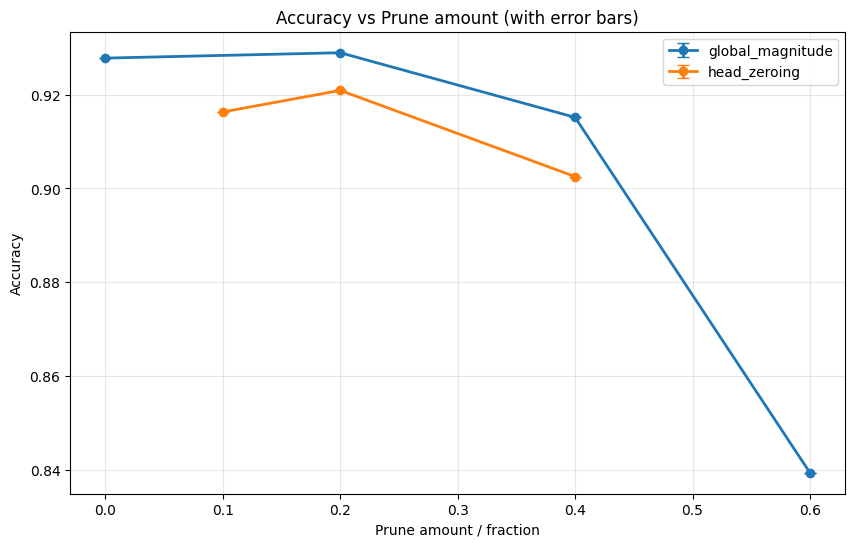

[codecarbon INFO @ 08:54:13] Energy consumed for RAM : 0.030972 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 08:54:13] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 08:54:13] Energy consumed for All CPU : 0.131868 kWh
[codecarbon INFO @ 08:54:13] Energy consumed for all GPUs : 0.178441 kWh. Total GPU Power : 64.72832585040736 W
[codecarbon INFO @ 08:54:13] 0.341282 kWh of electricity used since the beginning.


Saved plot to /content/pruning_plots_Latency_(ms).png


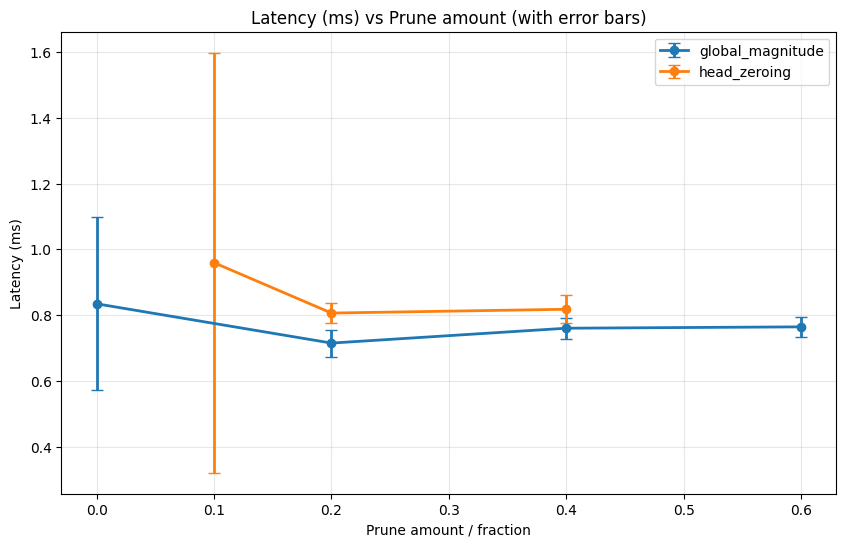

Saved plot to /content/pruning_plots_Emissions_(kg_CO2_eq).png


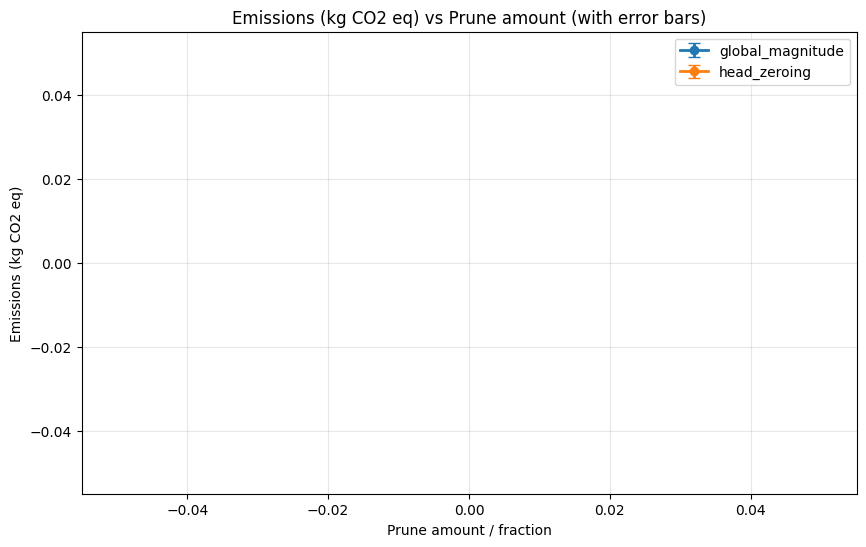

Radar chart saved to /content/pruning_plots_radar.png


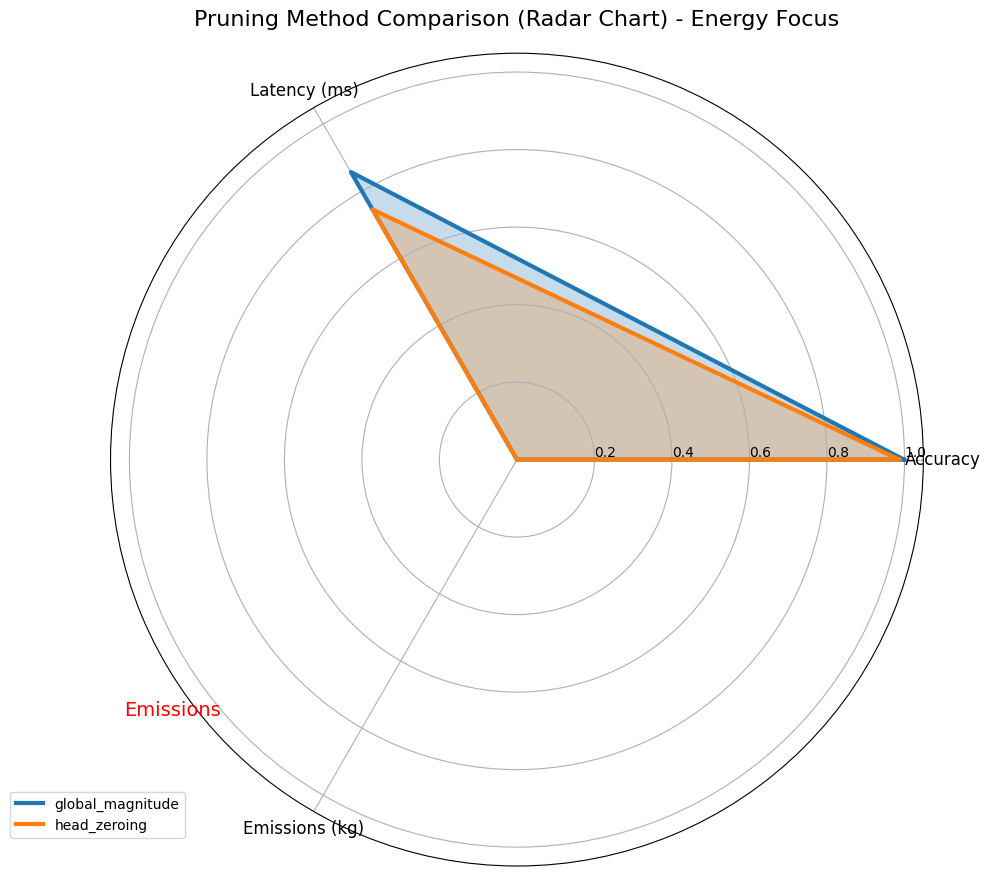

In [21]:
# Aggregation and plotting of results (after experiments complete)
def aggregate_and_plot(results_csv=RESULTS_CSV, output_prefix='/content/pruning_plots'):
    df = pd.read_csv(results_csv)

    # Convert emissions field to numeric where possible (attempt to parse 'emissions_kg' or 'emissions' keys)
    def extract_emissions(s):
        if pd.isna(s) or s == '':
            return np.nan
        try:
            d = eval(s)
            if isinstance(d, dict):
                for k in ['emissions_kg','emissions','energy_consumed']:
                    if k in d:
                        return float(d[k])
            return np.nan
        except Exception:
            return np.nan
    df['emissions_val'] = df['emissions'].apply(extract_emissions)

    # Group and aggregate
    summary = df.groupby(['pruning_type', 'prune_amount']).agg({
        'accuracy': ['mean', 'std'],
        'avg_latency_ms': ['mean', 'std'],
        'cpu_rss_mb': ['mean', 'std'],
        'gpu_mem_mb': ['mean', 'std'],
        'emissions_val': ['mean', 'std']
    }).reset_index()

    # Flatten multi-level columns correctly
    summary.columns = ['_'.join(col).strip() if col[1] else col[0] for col in summary.columns.values]

    print("Summary Statistics:")
    print(summary.head(20))

    # Plot: accuracy vs prune amount
    for metric_name, col_mean, col_std in [
        ('Accuracy', 'accuracy_mean', 'accuracy_std'),
        ('Latency (ms)', 'avg_latency_ms_mean', 'avg_latency_ms_std'),
        ('Emissions (kg CO2 eq)', 'emissions_val_mean', 'emissions_val_std')
    ]:
        plt.figure(figsize=(10, 6))
        for ptype in summary['pruning_type'].unique():
            sub = summary[summary['pruning_type'] == ptype]
            x = sub['prune_amount']
            y = sub[col_mean]
            yerr = sub[col_std].fillna(0)
            plt.errorbar(x, y, yerr=yerr, label=ptype, marker='o', capsize=4, linewidth=2)
        plt.xlabel('Prune amount / fraction')
        plt.ylabel(metric_name)
        plt.title(f'{metric_name} vs Prune amount (with error bars)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        out_file = f"{output_prefix}_{metric_name.replace(' ','_').replace(' (kg CO2 eq)', '')}.png"
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        print(f'Saved plot to {out_file}')
        plt.show()

    # Radar chart for multi-metric comparison across pruning types
    def radar_chart_summary(summary):
        # Select representative pruning levels for radar chart
        metrics = ['accuracy_mean', 'avg_latency_ms_mean', 'emissions_val_mean']
        metric_labels = ['Accuracy', 'Latency (ms)', 'Emissions (kg)']

        # Normalize metrics (higher is better for accuracy, lower for others)
        summary_norm = summary.copy()
        for m in metrics:
            if m == 'accuracy_mean':
                summary_norm[m] = summary_norm[m] / summary_norm[m].max()
            else:
                summary_norm[m] = 1 / (summary_norm[m] / summary_norm[m].min()) if summary_norm[m].min() > 0 else 0

        N = len(metrics)
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles += angles[:1]

        plt.figure(figsize=(10, 10))
        ax = plt.subplot(111, polar=True)

        # Plot for each pruning type at a fixed prune amount (e.g., 0.4)
        for ptype in summary_norm['pruning_type'].unique():
            sub = summary_norm[summary_norm['pruning_type'] == ptype]
            if len(sub) > 0:
                row = sub.iloc[0]  # Take first row for representative
                values = [row[m] for m in metrics]
                values += values[:1]
                ax.plot(angles, values, linewidth=3, label=ptype)
                ax.fill(angles, values, alpha=0.25)

        plt.xticks(angles[:-1], metric_labels, size=12)
        plt.title("Pruning Method Comparison (Radar Chart) - Energy Focus", size=16, pad=20)
        ax.set_rlabel_position(0)
        plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], size=10)
        plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))
        plt.grid(True)

        # Highlight energy usage
        ax.text(angles[2] * 0.9, 1.1, "Emissions", ha="center", va="center", color="red", fontsize=14)

        plt.tight_layout()
        radar_file = f"{output_prefix}_radar.png"
        plt.savefig(radar_file, dpi=300, bbox_inches='tight')
        print(f'Radar chart saved to {radar_file}')
        plt.show()

    # Generate radar chart
    radar_chart_summary(summary)

    return summary

# Run experiments
results_csv = run_pruning_experiments()

# Aggregate and plot results
summary = aggregate_and_plot(results_csv)



In [22]:
# ONNX export + ONNX Runtime (CPU) inference for pruned model
def export_to_onnx(model, tokenizer, export_path='/content/pruned_model.onnx', sample_text='This is a test sentence.', device=DEVICE):
    model.to('cpu')  # export on CPU to simplify
    model.eval()
    tokens = tokenizer(sample_text, return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LENGTH)
    input_names = ['input_ids', 'attention_mask']
    output_names = ['logits']
    try:
        torch.onnx.export(model, (tokens['input_ids'], tokens['attention_mask']), export_path,
                          input_names=input_names, output_names=output_names,
                          opset_version=17,  # Increased to latest supported opset
                          dynamic_axes={'input_ids': {0: 'batch_size'}, 'attention_mask': {0: 'batch_size'}})
        print('ONNX exported to', export_path)

        # Simplify the ONNX model to resolve unsupported operators (if available)
        model_simp, check = simplify(export_path)
        if check:
            print(f"ONNX model simplified and saved to {export_path}")
        else:
            print("ONNX simplification failed, using original model")

        # Log ONNX export to WandB
        wandb.log({"onnx_exported": {"path": export_path}})
    except Exception as e:
        print(f"ONNX export failed: {str(e)}. Please check the model structure or try a different opset version.")
        raise

    return export_path

def run_onnx_inference(onnx_path, tokenizer, texts, batch_size=8):
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    input_name_ids = sess.get_inputs()[0].name
    input_name_mask = sess.get_inputs()[1].name
    results = []
    tracker = OfflineEmissionsTracker(country_iso_code="DEU", save_to_file=False, log_level='info')
    tracker.start()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        toks = tokenizer(batch_texts, truncation=True, padding='max_length', max_length=MAX_LENGTH, return_tensors='np')
        ort_inputs = {input_name_ids: toks['input_ids'], input_name_mask: toks['attention_mask']}
        t0 = time.perf_counter()
        out = sess.run(None, ort_inputs)
        t1 = time.perf_counter()
        logits = out[0]
        preds = np.argmax(logits, axis=-1)
        results.extend(preds.tolist())

    emissions = tracker.stop()

    # Log ONNX inference to WandB
    wandb.log({
        "onnx_inference_time_s": time.perf_counter() - t0,
        "onnx_emissions_kg": emissions.emissions if hasattr(emissions, 'emissions') else emissions
    })

    return results

# Example usage after running experiments:
# Load a pruned model for ONNX export (example with global magnitude pruning 0.4)
pruned_model = prune_model_global_magnitude(_copy.deepcopy(base_model), amount=0.4, prune_in_place=True)
# Initialize a new WandB run for ONNX export and inference
wandb.init(project="pruning_experiments", name="onnx_export_inference", config={"model_name": MODEL_NAME})
export_path = export_to_onnx(pruned_model, tokenizer, export_path='/content/pruned_model.onnx')
preds = run_onnx_inference(export_path, tokenizer, ['I love this movie', 'I hate this movie'])
print("ONNX predictions:", preds)
wandb.finish()  # Close the WandB run after ONNX steps

/tmp/ipython-input-3633415097.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, (tokens['input_ids'], tokens['attention_mask']), export_path,
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every

ONNX exported to /content/pruned_model.onnx


[codecarbon INFO @ 08:55:02] Energy consumed for RAM : 0.031108 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 08:55:02] Delta energy consumed for CPU with constant : 0.000222 kWh, power : 42.5 W
[codecarbon INFO @ 08:55:13] Energy consumed for All CPU : 0.132444 kWh
[codecarbon INFO @ 08:55:19] Energy consumed for all GPUs : 0.179088 kWh. Total GPU Power : 35.122141524103284 W
[codecarbon INFO @ 08:55:19] 0.342640 kWh of electricity used since the beginning.
[codecarbon INFO @ 08:55:19] Energy consumed for RAM : 0.031108 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 08:55:19] Delta energy consumed for CPU with constant : 0.000000 kWh, power : 42.5 W
[codecarbon INFO @ 08:55:19] Energy consumed for All CPU : 0.132444 kWh
[codecarbon INFO @ 08:55:25] Energy consumed for all GPUs : 0.179088 kWh. Total GPU Power : 0.0 W
[codecarbon INFO @ 08:55:25] 0.342640 kWh of electricity used since the beginning.
[codecarbon INFO @ 08:55:41] Energy consumed for RAM : 0.031140 kWh. RAM Power : 10.0 W
[codeca

ONNX model simplified and saved to /content/pruned_model.onnx


[codecarbon INFO @ 08:56:17] 0.343787 kWh of electricity used since the beginning.
[codecarbon INFO @ 08:56:17] Energy consumed for all GPUs : 0.179660 kWh. Total GPU Power : 0.28073473809182053 W
[codecarbon INFO @ 08:56:17] 0.343787 kWh of electricity used since the beginning.
[codecarbon INFO @ 08:56:17] offline tracker init
[codecarbon WARNING @ 08:56:17] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 08:56:17] [setup] RAM Tracking...
[codecarbon INFO @ 08:56:17] [setup] CPU Tracking...
[codecarbon WARNING @ 08:56:18] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 08:56:18] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 08:56:18] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WA

ONNX predictions: [1, 0]


onnx_emissions_kg,▁
onnx_inference_time_s,▁
onnx_emissions_kg,0.0
onnx_inference_time_s,0.4959



## How to run
1. (Optional) Install required packages in a notebook cell (see install cell). If running in Colab, run the install cell and then **restart runtime** if necessary.

2. Run cells in order.

3. To execute experiments, run:

```python
results_file = run_pruning_experiments()
```

4. After experiments finish, aggregate and plot:

```python
summary = aggregate_and_plot(results_file)
```

5. To export to ONNX and run ONNX Runtime CPU inference follow the ONNX cell examples.


**Reproducibility tips:** record environment info (torch, cuda, CPU/GPU models) and run each experiment multiple times.
